In [ ]:
from fiatlux.optical_elements.mask import CircularAperture
from fiatlux.grid import Grid
from fiatlux.spectrum import *
from fiatlux.source import *
from fiatlux.propagator import MFTPropagator

import matplotlib.pyplot as plt

In [ ]:
spectrum = Spectrum(PhotometricBand.I4, 10)

source = PlaneWave(spectrum=spectrum, incidence_angle=IncidenceAngle(tip=0, tilt=0))
grid = Grid(nx=128, ny=128, dx=1 / 128, dy=1 / 128)

TypeError: Field.__init__() missing 1 required positional argument: 'grid'

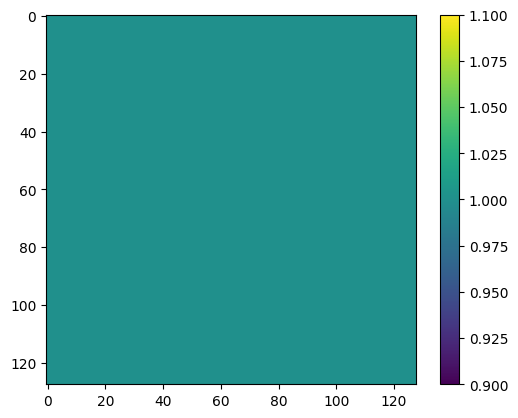

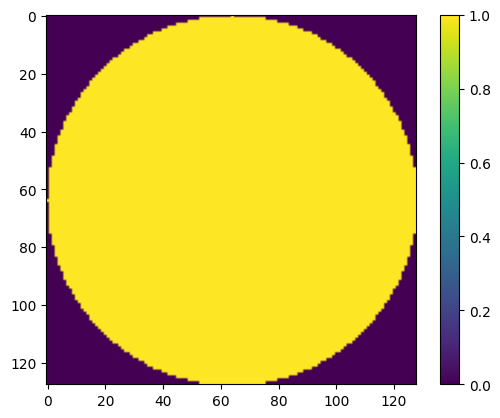

In [ ]:
field = source.generate_field(grid)
aperture = CircularAperture(radius=0.5, grid=grid)

plt.figure()
plt.imshow(torch.abs(field.complex_amplitude[0, ...]))
plt.colorbar()

aperture.build()

plt.figure()
plt.imshow(torch.abs(aperture.complex_transmission))
plt.colorbar()

field2 = aperture.apply(field)

plt.figure()
plt.imshow(torch.abs(field2.complex_amplitude))
plt.colorbar()

In [13]:
mft = MFTPropagator()

In [14]:
field3 = mft.propagate(field2, grid)

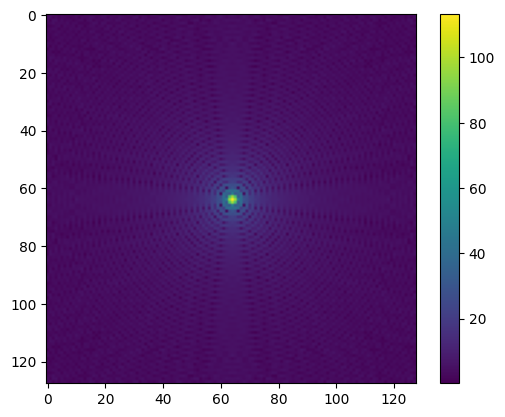

In [15]:
plt.imshow((torch.abs(field3.complex_amplitude)) ** 0.5)
plt.colorbar()

In [29]:
A = torch.rand((3, 3))
B = A.unsqueeze(0).expand(5, -1, -1)

print(A.shape)
print(B.shape)
print(A)
print(B)

torch.Size([3, 3])
torch.Size([5, 3, 3])
tensor([[0.0780, 0.2155, 0.2037],
        [0.0898, 0.9659, 0.7638],
        [0.8762, 0.8932, 0.1103]])
tensor([[[0.0780, 0.2155, 0.2037],
         [0.0898, 0.9659, 0.7638],
         [0.8762, 0.8932, 0.1103]],

        [[0.0780, 0.2155, 0.2037],
         [0.0898, 0.9659, 0.7638],
         [0.8762, 0.8932, 0.1103]],

        [[0.0780, 0.2155, 0.2037],
         [0.0898, 0.9659, 0.7638],
         [0.8762, 0.8932, 0.1103]],

        [[0.0780, 0.2155, 0.2037],
         [0.0898, 0.9659, 0.7638],
         [0.8762, 0.8932, 0.1103]],

        [[0.0780, 0.2155, 0.2037],
         [0.0898, 0.9659, 0.7638],
         [0.8762, 0.8932, 0.1103]]])


In [7]:
field = source.generate_field(grid)

In [8]:
plt.imshow(torch.angle(field.amplitude))
plt.colorbar()

AttributeError: 'Field' object has no attribute 'amplitude'